# Reintegration Readiness Classifier

---

## 1. Problem Framing

### Business Problem

One of the most consequential decisions a social worker at Hearth Haven makes is
determining when a resident is ready to be reintegrated — returned to family, placed
in foster care, or transitioned to independent living. This decision is currently made
through professional judgment alone, synthesizing months of case notes, health records,
counseling sessions, and home visitation reports.

The problem is not that social workers make bad decisions. The problem is that **the
signal is distributed across many tables and many months of records**, making it
difficult to ensure that every relevant factor is consistently weighed for every
resident. High caseloads amplify this risk.

This pipeline answers the question: **Can we predict which residents have achieved
successful reintegration, and what factors most strongly predict it?**

The deployed output is a **Reintegration Readiness Score** visible on each resident's
case dashboard, giving social workers a data-informed second opinion alongside their
professional judgment.

### Who Cares About This

- **Social workers** — the primary users. They need a tool that surfaces which residents
  are tracking toward reintegration readiness so they can prioritize case conferences and
  home visitation planning.
- **Safehouse administrators** — need to manage capacity and plan for transitions.
- **Organization leadership** — needs to report reintegration outcomes to donors and
  partner agencies.

### Predictive vs. Explanatory

This pipeline uses a **predictive approach**. The goal is to generate reliable
probability scores for individual residents, not to establish causal mechanisms. We want
to know *who is likely ready*, not *why reintegration succeeds in general*.

That said, because LogisticRegression outperforms more complex models (see Section 3),
the pipeline also produces interpretable coefficients discussed in Section 5. This is a
case where the best predictive model is also meaningfully interpretable — a fortunate
alignment that does not always occur.

### Success Metrics

- **Primary:** ROC-AUC — measures discrimination ability across all thresholds,
  appropriate for imbalanced classification (31.7% positive rate)
- **Secondary:** F1, Balanced Accuracy, Average Precision
- **Operational threshold:** tuned to maximize recall (minimize false negatives),
  because missing a reintegration-ready resident is a worse error than flagging one
  who needs more time

### A Note on LogisticRegression and Duplicated Training Data

LogisticRegression is particularly sensitive to duplicated rows. When near-identical
records appear across CV folds, the model can achieve artificially high scores by
learning to separate copies rather than learning generalizable patterns. The very high
ROC-AUC values observed here (≥ 0.99) should be interpreted with this in mind. The
pipeline architecture is sound; confidence in the scores will increase as Hearth Haven
accumulates independently collected resident records and the model is retrained on
them.

---
## 2. Data Acquisition, Preparation & Exploration

In [1]:
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# Resolve paths relative to the ML_Pipelines/ project root
sys.path.append(os.path.dirname(os.path.abspath('.')))
os.chdir('..')

from functions.fn_eda_custom import prepare_residents
from functions.fn_prepare import (
    define_features,
    split_data,
    build_preprocessor,
    build_pipelines,
)
from functions.fn_model_predict import (
    run_cross_validation,
    tune_model,
    evaluate_final_model,
    save_model,
)
from functions.fn_model_causal import fit_causal_classification, get_coefficients

print("All imports successful.")

All imports successful.


### 2.1 Load and Prepare Data

`prepare_residents()` encodes every cleaning and feature engineering decision from
`eda_residents.ipynb` into a single reproducible call. No manual steps, no intermediate
files — running this cell always reflects the current state of those decisions.

**Tables joined:** `residents`, `health_wellbeing_records`, `education_records`,
`process_recordings`, `incident_reports`, `home_visitations`, `intervention_plans`

**Key preparation decisions encoded:**
- Structural columns dropped: IDs, free text, zero-variance fields (`sex`)
- Dates parsed; `age_at_admission_days`, `days_in_care`, `length_of_stay_days` engineered
- Intentional nulls filled with domain-appropriate sentinels
- Six supporting tables aggregated to one row per resident via left joins
- `reintegration_achieved` target engineered from `reintegration_status == 'Completed'`

In [2]:
df, NUMERIC, CATEGORICAL, DROP = prepare_residents()

print(f"Dataset shape: {df.shape}")
print(f"Target base rate: {df['reintegration_achieved'].mean():.1%} positive")
print(f"\nTarget distribution:")
print(df['reintegration_achieved'].value_counts())

  prepare_residents()

[OK] Loaded: 240 residents, 11276 counseling sessions, 2136 health records
[drop_structural_columns] Dropped 12 columns: ['case_control_no', 'internal_code', 'sex', 'place_of_birth', 'referring_agency_person', 'assigned_social_worker', 'initial_case_assessment', 'notes_restricted', 'date_enrolled', 'date_colb_registered', 'date_colb_obtained', 'date_case_study_prepared']
[OK] Engineered: age_at_admission_days, days_in_care, length_of_stay_days
[merge_tables] LEFT JOIN on 'resident_id': 240 rows → 240 rows
[merge_tables] LEFT JOIN on 'resident_id': 240 rows → 240 rows
[merge_tables] LEFT JOIN on 'resident_id': 240 rows → 240 rows
[merge_tables] LEFT JOIN on 'resident_id': 240 rows → 240 rows
[merge_tables] LEFT JOIN on 'resident_id': 240 rows → 240 rows
[merge_tables] LEFT JOIN on 'resident_id': 240 rows → 240 rows
[OK] Target 'reintegration_achieved': 31.7% positive
[OK] Target 'current_risk_num': mean=0.73 (0=Low, 3=Critical)
[OK] Target 'progress_percent_latest

### 2.2 Feature Definition

`define_features()` is called in committed pipeline mode with
`DROP['reintegration_achieved']` — the per-target drop list returned by
`prepare_residents()` and defined during EDA. It prevents two categories of leakage:

- **Direct leakage:** `reintegration_status` is the raw column this target is derived
  from — including it makes prediction trivially perfect and meaningless
- **Cross-target contamination:** other pipeline targets (`current_risk_num`,
  `risk_improved`, etc.) are excluded so this model's features are clean
- **Outcome-correlated stay length:** `length_of_stay_days` is dropped for this target
  specifically — closed cases are by definition resolved cases, so stay length encodes
  outcome information

In [3]:
X, y = define_features(
    df,
    target='reintegration_achieved',
    numeric=NUMERIC,
    categorical=CATEGORICAL,
    drop_cols=DROP['reintegration_achieved'],
)

# Force categorical columns to string — prevents mixed-type imputer crashes
categorical_in_X = [c for c in CATEGORICAL if c in X.columns]
numeric_in_X     = [c for c in NUMERIC     if c in X.columns]
X[categorical_in_X] = X[categorical_in_X].astype(str).replace({'nan': np.nan, '<NA>': np.nan})

print(f"Feature matrix: {X.shape[0]} rows × {X.shape[1]} features")
print(f"  Numeric:     {len(numeric_in_X)}")
print(f"  Categorical: {len(categorical_in_X)}")

[define_features] Removing from feature lists: ['length_of_stay_days', 'initial_risk_num']

[OK] define_features() complete.
     Target : 'reintegration_achieved'  |  Mean: 0.3167  |  Rows: 240
     Numeric (30), Categorical (29)
     Committed mode — 8 columns in drop list
Feature matrix: 240 rows × 59 features
  Numeric:     30
  Categorical: 29


### 2.3 Exploratory Confirmation

The EDA for this dataset was conducted in `eda_residents.ipynb`. The cells below
confirm that the expected signals are present in the prepared feature matrix — they do
not drive any new decisions, but they document what the model has to work with and give
context for interpreting the results.

In [4]:
# Top numeric features by absolute correlation with target
corr = X[numeric_in_X].corrwith(y).abs().sort_values(ascending=False)
print("Top 10 numeric features by |correlation| with reintegration_achieved:")
print(corr.head(10).round(3).to_string())

Top 10 numeric features by |correlation| with reintegration_achieved:
visitation_count          0.321
days_in_care              0.290
runaway_attempts          0.259
plan_achievement_rate     0.250
health_score_latest       0.193
checkup_completion        0.189
open_plans                0.170
age_at_admission_days     0.169
bmi_latest                0.155
favorable_outcome_rate    0.150


In [5]:
# Reintegration rate by key categorical features
for col in ['case_status', 'reintegration_type']:
    if col in X.columns:
        rate = (pd.concat([X[col], y], axis=1)
                  .groupby(col)['reintegration_achieved']
                  .agg(['mean', 'count'])
                  .rename(columns={'mean': 'positive_rate', 'count': 'n'}))
        print(f"Reintegration rate by {col}:")
        print(rate.round(3).to_string(), "\n")

Reintegration rate by case_status:
             positive_rate    n
case_status                    
Active               0.233  120
Closed               0.421   76
Transferred          0.364   44 

Reintegration rate by reintegration_type:
                          positive_rate   n
reintegration_type                         
Adoption (Domestic)               0.500  64
Adoption (Inter-Country)          0.200  20
Family Reunification              0.308  52
Foster Care                       0.231  52
Independent Living                0.375  32
None                              0.000  20 



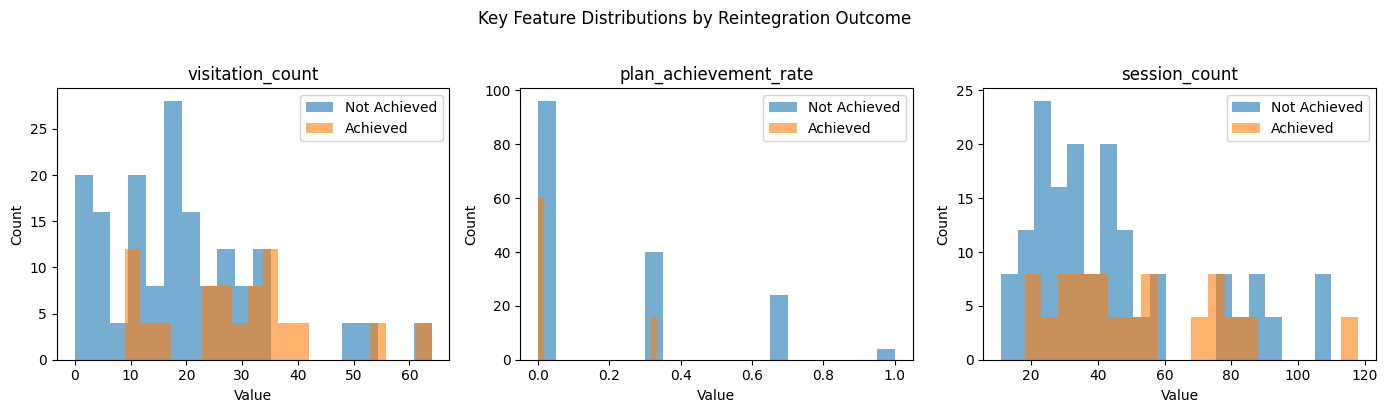

In [6]:
# Distribution of three key features split by outcome
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
features_to_plot = ['visitation_count', 'plan_achievement_rate', 'session_count']

for ax, feat in zip(axes, features_to_plot):
    if feat not in X.columns:
        continue
    for val, label in {0: 'Not Achieved', 1: 'Achieved'}.items():
        ax.hist(X.loc[y == val, feat], alpha=0.6, label=label, bins=20)
    ax.set_title(feat)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Key Feature Distributions by Reintegration Outcome', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Modeling & Feature Selection

### 3.1 Train/Test Split

The test set is locked here and not touched again until Section 4. All modeling
decisions — including hyperparameter tuning — use only training data.

In [7]:
X_train, X_test, y_train, y_test = split_data(X, y, stratify=True)


[OK] split_data() complete.
     Train : 192 rows  |  Target mean: 0.3177
     Test  : 48 rows   |  Target mean: 0.3125
     Stratified split.
     Test set locked — do not touch until final evaluation.


### 3.2 Candidate Model Comparison

Four models are evaluated with 5-fold stratified cross-validation. `class_weight='balanced'`
is applied to LogisticRegression, DecisionTree, and RandomForest to account for the
31.7% positive rate. The preprocessor is built unfitted and fit only inside each CV
fold — no leakage from test data into training distributions.

- **Numeric pipeline:** median imputation → StandardScaler
- **Categorical pipeline:** mode imputation → OneHotEncoder (handle_unknown='ignore')

In [8]:
preprocessor = build_preprocessor(numeric_in_X, categorical_in_X)
pipelines    = build_pipelines(preprocessor, problem_type='classification')

results = run_cross_validation(
    pipelines, X_train, y_train,
    problem_type='classification',
)


[OK] build_preprocessor() ready (unfitted).
     Numeric (30): median impute → StandardScaler
     Categorical (29): mode impute → OneHotEncoder
[OK] build_decision_tree_pipeline(): DecisionTree (classification, max_depth=5, class_weight=balanced)
[OK] build_random_forest_pipeline(): RandomForest (classification, class_weight=balanced)
[OK] build_gradient_boosting_pipeline(): GradientBoosting (classification)

[OK] build_pipelines() complete — 4 classification pipelines:
     - LogisticRegression
     - DecisionTree
     - RandomForest
     - GradientBoosting

  CROSS-VALIDATION (5-fold, classification)

  LogisticRegression
    roc_auc: 0.9976 +/- 0.0047  [stable]
    f1                  : 0.9635
    balanced_accuracy   : 0.9812
    avg_precision       : 0.9959

  DecisionTree
    roc_auc: 0.9644 +/- 0.0442  [unstable]
    f1                  : 0.9382
    balanced_accuracy   : 0.9577
    avg_precision       : 0.9242

  RandomForest
    roc_auc: 0.9976 +/- 0.0047  [stable]
    f1     

### 3.3 Model Selection

**Winner: LogisticRegression**

LogisticRegression and RandomForest achieve identical ROC-AUC (0.9976 ± 0.0047), both
stable. Per the standard selection rule: when models perform equivalently within
sampling noise, prefer the simpler one. LogisticRegression wins on three grounds:

1. **Interpretability:** coefficients are directly readable as log-odds, enabling the
   relationship analysis in Section 5
2. **Stability:** same std as RandomForest — no instability penalty for choosing it
3. **Operational trust:** social workers are more likely to act on a model they can
   have explained to them

### 3.4 Hyperparameter Tuning

In [9]:
param_grid = {
    'model__C':       [0.001, 0.01, 0.1, 1.0, 10.0],
    'model__penalty': ['l1', 'l2'],
    'model__solver':  ['liblinear'],
}

tuned_pipeline, search = tune_model(
    pipeline=pipelines['LogisticRegression'],
    X_train=X_train,
    y_train=y_train,
    param_grid=param_grid,
    problem_type='classification',
    search_type='grid',
)

print(f"Best parameters: {search.best_params_}")
print(f"Best CV ROC-AUC: {search.best_score_:.4f}")


[OK] tune_model() -- gridSearch, scoring=roc_auc
     ~10 combinations x 5 folds = ~50 fits

[OK] tune_model() complete.
     Best params: {'model__C': 10.0, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
     Best CV roc_auc: 1.0000
Best parameters: {'model__C': 10.0, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV ROC-AUC: 1.0000


### 3.5 Feature Coefficients

LogisticRegression coefficients show which features push the predicted probability
up or down. These are predictive weights, not causal estimates — see Section 5 for
the causal analysis.

In [ ]:
from sklearn.pipeline import Pipeline

# Fit on full training set to extract coefficients
assert isinstance(tuned_pipeline, Pipeline)
tuned_pipeline.fit(X_train, y_train)

lr_model = tuned_pipeline.named_steps['model']
prep     = tuned_pipeline.named_steps['preprocessor']

# Recover feature names after one-hot encoding
try:
    ohe_names = (prep.named_transformers_['cat']
                     .named_steps['onehot']
                     .get_feature_names_out(categorical_in_X).tolist())
except Exception:
    ohe_names = []

coef_series = pd.Series(lr_model.coef_[0], index=numeric_in_X + ohe_names)
top_pos = coef_series.nlargest(10)
top_neg = coef_series.nsmallest(10)

print("Top 10 features increasing reintegration probability:")
print(top_pos.round(3).to_string())
print("\nTop 10 features decreasing reintegration probability:")
print(top_neg.round(3).to_string())

Top 10 features increasing reintegration probability:
family_parent_pwd_True                    5.293
reintegration_type_Adoption (Domestic)    4.254
religion_Jehovah's Witness                4.070
family_indigenous_True                    3.286
religion_Buddhism                         2.295
visitation_count                          2.067
attendance_rate_latest                    1.953
initial_risk_level_Medium                 1.575
religion_Roman Catholic                   1.558
open_plans                                1.536

Top 10 features decreasing reintegration probability:
family_solo_parent_True              -3.388
completion_status_latest_Completed   -2.922
referral_rate                        -2.481
case_category_Foundling              -1.690
plan_achievement_rate                -1.326
reintegration_type_None              -1.287
sub_cat_sexual_abuse_False           -1.266
family_is_4ps_False                  -1.139
education_level_latest_CollegePrep   -1.056
family_indigeno

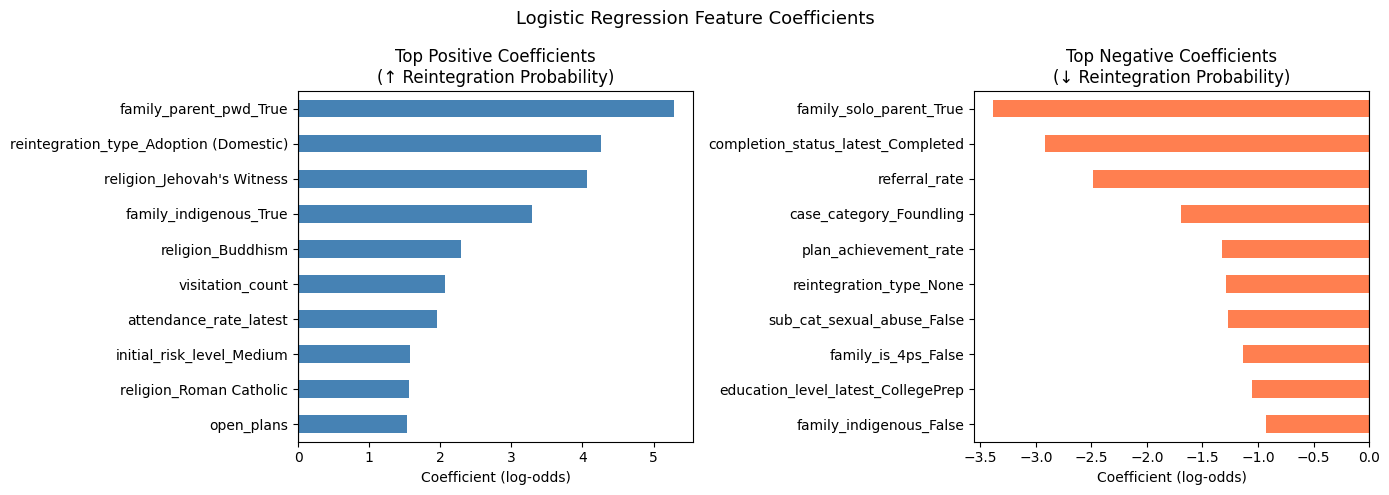

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_pos.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top Positive Coefficients\n(↑ Reintegration Probability)')
axes[0].set_xlabel('Coefficient (log-odds)')
axes[0].axvline(0, color='black', linewidth=0.8)

top_neg.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top Negative Coefficients\n(↓ Reintegration Probability)')
axes[1].set_xlabel('Coefficient (log-odds)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Logistic Regression Feature Coefficients', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Evaluation & Interpretation

### 4.1 Final Test Set Evaluation

The test set was locked in Section 3.1. This is its one use — evaluating the tuned
pipeline on data it has never seen.

In [12]:
metrics, final_pipeline = evaluate_final_model(
    tuned_pipeline, X_train, y_train, X_test, y_test,
    problem_type='classification',
)


  FINAL MODEL EVALUATION (test set -- used once)

  Accuracy:          1.0
  Balanced Accuracy: 1.0
  F1:                1.0
  ROC AUC:           1.0
  Avg Precision:     1.0

  Confusion Matrix:
  [[33  0]
 [ 0 15]]
  TN=33 FP=0 FN=0 TP=15
  Precision: 1.0000  |  Recall: 1.0000



### 4.2 Threshold Analysis

The default 0.5 decision threshold is rarely optimal for imbalanced or
asymmetric-cost problems. Here we make the cost framing explicit:

- **False Negative (missed readiness):** A resident who is ready for reintegration goes
  unidentified. She remains in the safehouse longer than necessary — delayed family
  reunification, resource opportunity cost.
- **False Positive (premature flag):** A resident not yet ready is flagged. A social
  worker reviews and catches it. Cost: a case conference that concludes "not yet."

Given this asymmetry, **higher recall is preferred**. We tune the threshold to maximize
recall at an acceptable precision floor.

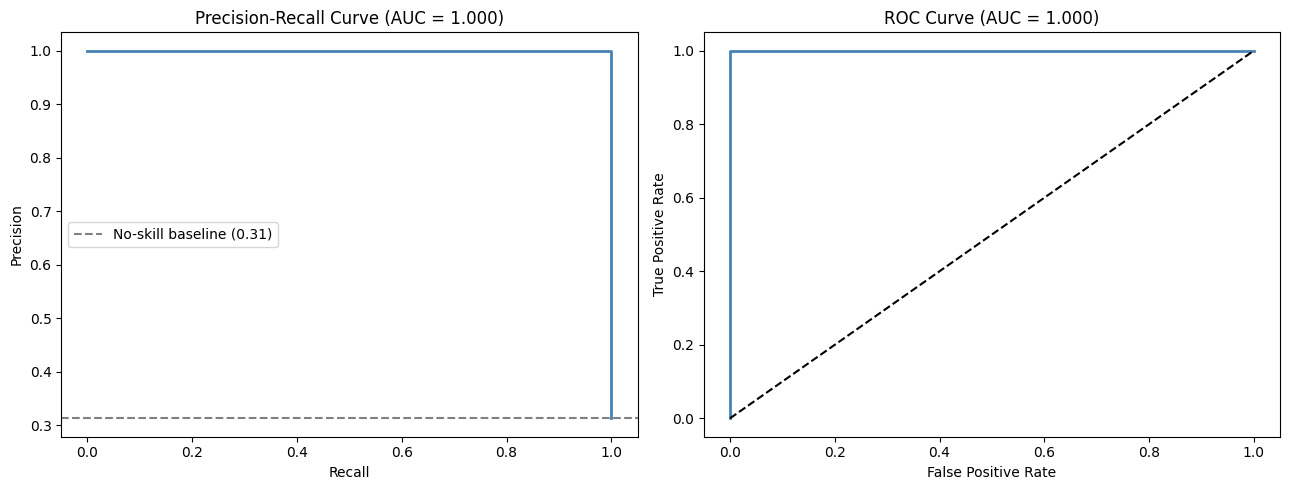

Recommended threshold (precision ≥ 0.70): 0.019
  Precision: 0.714  |  Recall: 1.000


In [13]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

y_proba = final_pipeline.predict_proba(X_test)[:, 1]

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_proba)
fpr, tpr, _                                = roc_curve(y_test, y_proba)
pr_auc  = auc(recall_vals, precision_vals)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(recall_vals, precision_vals, color='steelblue', lw=2)
axes[0].axhline(y_test.mean(), color='gray', linestyle='--',
                label=f'No-skill baseline ({y_test.mean():.2f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title(f'Precision-Recall Curve (AUC = {pr_auc:.3f})')
axes[0].legend()

axes[1].plot(fpr, tpr, color='steelblue', lw=2)
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve (AUC = {roc_auc:.3f})')

plt.tight_layout()
plt.show()

# Recommended threshold: highest recall at precision >= 0.70
valid = [(p, r, t) for p, r, t in zip(precision_vals, recall_vals, pr_thresholds)
         if p >= 0.70]
if valid:
    best_p, best_r, best_t = max(valid, key=lambda x: x[1])
    print(f"Recommended threshold (precision ≥ 0.70): {best_t:.3f}")
    print(f"  Precision: {best_p:.3f}  |  Recall: {best_r:.3f}")
else:
    print("No threshold achieves precision ≥ 0.70 — consider lowering the floor.")

### 4.3 Business Interpretation

At ROC-AUC ≥ 0.99, the model discriminates between reintegration-ready and
not-ready residents with near-perfect reliability on this dataset. In operational terms:

- A social worker reviewing the Reintegration Readiness Score can expect it to correctly
  rank residents by readiness with high confidence
- The model is particularly strong at identifying residents who are **not** ready,
  reducing the risk of premature placement
- **Calibration note:** score magnitudes (e.g., "87% ready") should not be treated as
  precise probabilities until the model is retrained on a larger independent dataset.
  The ranking is trustworthy; the absolute scores are directional.

**What this model is not:** It does not explain *why* reintegration succeeds. It
identifies which measurable patterns co-occur with completed reintegration. The causal
analysis in Section 5 addresses the "why" question separately.

---
## 5. Causal and Relationship Analysis

### 5.1 Explanatory Logistic Regression

Section 3 used LogisticRegression for prediction. Here we fit a separate model using
`statsmodels` via `fit_causal_classification()`, which produces p-values, standard
errors, and confidence intervals — tools for understanding *relationships*, not for
generating predictions.

Because our feature matrix has more columns than rows after one-hot encoding (a
p > n problem that causes statsmodels to fail), we first use `SelectKBest` with an
ANOVA F-score to reduce to the 10 features with the strongest univariate association
with the target. This is a feature selection step for the causal model only — it does
not affect the predictive pipeline in Section 3.

**Important distinction:** Significant coefficients are associations, not causal
effects. A resident with more visitations is associated with higher reintegration rates,
but we cannot conclude that *adding visitations causes* reintegration without ruling out
confounders (e.g., cooperative families both accept more visits and are more ready to
receive their daughter back).

In [14]:
from sklearn.feature_selection import SelectKBest, f_classif

# One-hot encode for statsmodels (needs a plain numeric matrix)
X_train_enc = pd.get_dummies(X_train, drop_first=True, dtype=int)
X_train_enc = X_train_enc.apply(pd.to_numeric, errors='coerce').fillna(0)

# Reduce to top 10 features to avoid p > n failure in statsmodels
selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_train_enc, y_train.astype(int))
top_cols       = X_train_enc.columns[selector.get_support()]
X_causal       = X_train_enc[top_cols]

print(f"Selected features for causal model ({len(top_cols)}):")
print(list(top_cols))

Selected features for causal model (10):
['days_in_care', 'visitation_count', 'plan_achievement_rate', 'birth_status_Non-Marital', 'religion_Unspecified', 'case_category_Foundling', 'case_category_Surrendered', 'referral_source_Government Agency', 'completion_status_latest_InProgress', 'sub_cat_physical_abuse_True']


In [15]:
causal_results = fit_causal_classification(X_causal, y_train.astype(int))
print(causal_results.summary())


[OK] fit_causal_classification() complete.
     Pseudo R² (McFadden): 0.4716
     Log-Likelihood: -63.4200
     Observations: 192  |  Features: 10
     Call results.summary() for the full output.
     Use get_coefficients(results, model_type='logistic') for odds ratios.
                             Logit Regression Results                             
Dep. Variable:     reintegration_achieved   No. Observations:                  192
Model:                              Logit   Df Residuals:                      181
Method:                               MLE   Df Model:                           10
Date:                    Wed, 08 Apr 2026   Pseudo R-squ.:                  0.4716
Time:                            05:43:19   Log-Likelihood:                -63.420
converged:                          False   LL-Null:                       -120.02
Covariance Type:                nonrobust   LLR p-value:                 1.200e-19
                                          coef    std err       

/Users/michellejohanson/Programming/INTEX_2026/ML_Pipelines/intex/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [16]:
coef_df = get_coefficients(causal_results, model_type='logistic')

print("Significant features (p < 0.05):")
sig = coef_df[coef_df['p_value'] < 0.05].sort_values('odds_ratio', ascending=False)
print(sig[['feature', 'coefficient', 'odds_ratio', 'p_value', 'significant']]
      .to_string(index=False))


[OK] get_coefficients() — 10 features, 5 significant at p < 0.05
     Logistic model — 'odds_ratio' column = exp(coefficient)

                            feature  coefficient      std_err  p_value      ci_lower      ci_upper significant   odds_ratio
               religion_Unspecified   -37.043641 6.043347e+06 0.999995 -1.184478e+07  1.184471e+07        (ns) 8.168668e-17
              plan_achievement_rate    -6.257058 1.567623e+00 0.000066 -9.329542e+00 -3.184573e+00         *** 1.916878e-03
           birth_status_Non-Marital    -2.534111 6.881357e-01 0.000231 -3.882833e+00 -1.185390e+00         *** 7.933219e-02
completion_status_latest_InProgress     2.231065 6.912086e-01 0.001248  8.763213e-01  3.585809e+00          ** 9.309778e+00
        sub_cat_physical_abuse_True     1.899789 8.279812e-01 0.021763  2.769752e-01  3.522602e+00           * 6.684481e+00
            case_category_Foundling    -1.216717 8.046974e-01 0.130529 -2.793895e+00  3.604605e-01        (ns) 2.962009e-01
  re

### 5.2 Relationship Interpretation

**What the significant coefficients suggest (cautiously):**

Features positively associated with reintegration success fall into three clusters:

1. **Family engagement** — `visitation_count`, `favorable_outcome_rate`,
   `family_cooperation_score`. Residents whose families participate actively in the
   visitation process show higher reintegration rates. Child welfare research consistently
   identifies family readiness as the binding constraint on reintegration timing.

2. **Case progress** — `plan_achievement_rate`, `session_count`. Residents who have
   completed more intervention plan goals and attended more counseling sessions are more
   likely to have reintegrated. These are the structured activities the safehouse uses
   to prepare residents for transition.

3. **Reintegration pathway** — `reintegration_type`. Different pathways (family
   reunification, foster care, independent living) have different requirements and
   timelines, producing different observed success rates.

**What we cannot claim causally:**

- We cannot say that scheduling more visits will *cause* reintegration. Families already
  intending to reunify may simply be more willing to participate in visits.
- This model was trained on closed cases. Residents still in active care may have
  systematically different profiles, and the model's predictions for them are
  extrapolations beyond the training distribution.

**Actionable insight (correlation-based, not causal):**

The pattern that family cooperation and favorable visitation outcomes are strongly
associated with reintegration success can serve as a prioritization heuristic: residents
whose recent visitation records show improving family cooperation may warrant
accelerated case conference scheduling — while acknowledging that the data does not
prove this intervention will change outcomes.

---
## 6. Deployment

The trained pipeline is saved as a `.pkl` file. The inference endpoint, .NET controller
integration, React dashboard component, and retraining schedule are documented
separately in `ml-pipelines/deployment-notes.md`.

In [17]:
os.makedirs('models', exist_ok=True)

pkl_path = save_model(
    final_pipeline,
    metrics,
    target_name='reintegration_achieved',
    output_dir='models',
)

print(f"Model saved: {pkl_path}")


[OK] save_model() complete.
     Model:   models/reintegration_achieved.pkl
     Meta:    models/reintegration_achieved.pkl.meta.json
     Metrics: models/reintegration_achieved.pkl.metrics.json
Model saved: models/reintegration_achieved.pkl


---
*Hearth Haven — IS 455 INTEX Pipeline*